In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import EvalCallback
import ta
import matplotlib.pyplot as plt


# Paths for saving models and logs
model_save_path = "models/periodic2"
os.makedirs(model_save_path, exist_ok=True)


# Load the existing model
model_path = "models/periodic2/final_model.zip"

# Load data and add indicators
df = pd.read_csv('EURUSD-Hour.csv')
df.columns = [ 'Date', 'Time', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'Bar Volume']
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)
df.sort_index(inplace=True)

'''
def add_indicators_with_crossovers(data):
    data['EMA_21'] = ta.trend.EMAIndicator(data['Close'], window=21).ema_indicator()
    data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=14).rsi()
    macd = ta.trend.MACD(data['Close'])
    data['MACD'] = macd.macd()
    data['MACD_Signal'] = macd.macd_signal()
    return data


df = add_indicators_with_crossovers(df)
'''

import ta

def add_indicators_with_crossovers(data):
    # Adding EMA
    data['EMA_4'] = ta.trend.EMAIndicator(data['Close'], window=144).ema_indicator()
    data['EMA_1'] = ta.trend.EMAIndicator(data['Close'], window=21).ema_indicator()
    data['EMA_2'] = ta.trend.EMAIndicator(data['Close'], window=55).ema_indicator()
    data['EMA_3'] = ta.trend.EMAIndicator(data['Close'], window=89).ema_indicator()

    # Adding SMA
    data['SMA_1'] = ta.trend.SMAIndicator(data['Close'], window=50).sma_indicator()
    data['SMA_2'] = ta.trend.SMAIndicator(data['Close'], window=200).sma_indicator()

    # Adding RSI
    data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=9).rsi()

    # Adding MACD
    macd = ta.trend.MACD(data['Close'], window_slow=26, window_fast=12, window_sign=9)
    data['MACD'] = macd.macd()
    data['MACD_Signal'] = macd.macd_signal()

    # Adding EMA Crossovers
    data['Fast_EMA'] = ta.trend.EMAIndicator(data['Close'], window=13).ema_indicator()
    data['Slow_EMA'] = ta.trend.EMAIndicator(data['Close'], window=48).ema_indicator()
    data['EMA_Crossover'] = data['Fast_EMA'] > data['Slow_EMA']

    # Adding Parabolic SAR
    data['Parabolic_SAR'] = ta.trend.PSARIndicator(data['High'], data['Low'], data['Close']).psar()

    # Adding ADX
    data['ADX'] = ta.trend.ADXIndicator(data['High'], data['Low'], data['Close'], window=14).adx()

    # Adding SuperTrend
    def supertrend(data, period, multiplier):
        st = ta.trend.STCIndicator(close=data['Close'], fillna=True, window_slow=period, window_fast=period//3).stc()
        data[f'SuperTrend_{period}_{multiplier}'] = st

    supertrend(data, period=7, multiplier=3)
    supertrend(data, period=10, multiplier=3)
    supertrend(data, period=20, multiplier=3)

    # Adding Bollinger Bands
    bb = ta.volatility.BollingerBands(close=data['Close'], window=20, window_dev=2)
    data['BB_High'] = bb.bollinger_hband()
    data['BB_Mid'] = bb.bollinger_mavg()
    data['BB_Low'] = bb.bollinger_lband()

    return data

df = add_indicators_with_crossovers(df)


df.dropna(inplace=True)

# Normalize data
df = (df - df.rolling(window=200).mean()) / (df.rolling(window=200).std() + 1e-8)
df.dropna(inplace=True)  # Ensure no NaNs after normalization

class TradingEnv(gym.Env):
    def __init__(self, df, initial_balance=10000, transaction_cost=0.0001):
        super(TradingEnv, self).__init__()
        self.df = df
        self.initial_balance = initial_balance
        self.transaction_cost = transaction_cost
        self.max_trade_fraction = 0.1  # Limit trades to 10% of current balance
        
        # Initialize variables
        self.current_step = 0
        self.current_balance = initial_balance
        self.net_worth = initial_balance
        self.position = 0
        self.equity_curve = []

        # Action space: Continuous action space for nuanced trading decisions
        self.action_space = spaces.Discrete(3)
        #self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        
        self.actions = []
        self.positions = []
        self.net_worths = []
        # Observation space: Adjust based on window size
        self.window_size = 20  # Define how much historical data to include
        self.observation_shape = self.window_size * len(df.columns) + 2
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(self.observation_shape,), 
            dtype=np.float32
        )

    def get_observation(self):
        """Generate the current observation."""
        # Get historical market data flattened to a 1D array
        market_data = np.nan_to_num(
            self.df.iloc[max(0, self.current_step - self.window_size):self.current_step].values.flatten()
        )
        # Include current balance and position in the observation
        additional_info = [self.current_balance / self.initial_balance, self.position]
        # Ensure observation shape matches the observation space
        observation = np.concatenate([market_data, additional_info])
        return observation

    def reset(self, seed=None, options=None):
        """Reset the environment for a new episode."""
        super().reset(seed=seed)
        self.current_step = self.window_size  # Start after the initial window
        self.current_balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.position = 0
        self.equity_curve = [self.initial_balance]
        self.returns = []  # Initialize returns list
        self.returns = self.returns[-100:]  # Keep only the last 100 returns
        return self.get_observation(), {}


    def step(self, action):
        """Perform one step in the environment."""
        self.current_step += 1
        terminated = False
        truncated = False

        if self.current_step >= len(self.df) - 1:
            terminated = True

        current_price = self.df.iloc[self.current_step]['Close']
        prev_net_worth = self.net_worth

        # Clip the action to ensure it's in the valid range
        action = np.clip(action[0], -1, 1)
        trade_amount = abs(action) * self.current_balance * self.max_trade_fraction
        
        
        if action > 0:  # Buy action
            units_to_buy = trade_amount / current_price
            transaction_fee = trade_amount * self.transaction_cost
            self.position += units_to_buy
            self.current_balance -= trade_amount + transaction_fee
        elif action < 0:  # Sell action
            units_to_sell = min(self.position, trade_amount / current_price)
            transaction_fee = units_to_sell * current_price * self.transaction_cost
            self.position -= units_to_sell
            self.current_balance += units_to_sell * current_price - transaction_fee
        

        # Ensure balances and positions are not negative
        self.current_balance = max(self.current_balance, 0)
        self.position = max(self.position, 0)

        # Update net worth
        self.net_worth = self.current_balance + self.position * current_price

        # Calculate reward
        reward = self.calculate_reward(prev_net_worth)

        # Append to equity curve
        self.equity_curve.append(self.net_worth)

        # Store data for plotting
        self.net_worths.append(self.net_worth)
        self.actions.append(action)
        self.positions.append(self.position)


        # Check for termination conditions
        #if self.net_worth <= 0.5 * self.initial_balance:
            #terminated = True

        return self.get_observation(), reward, terminated, truncated, {}
        

    def calculate_reward(self, prev_net_worth):
        '''initial
        # Simple reward based on net worth change
        reward = (self.net_worth - prev_net_worth) / (prev_net_worth + 1e-8)
        return reward'''

        # Calculate return
        profit = self.net_worth - prev_net_worth
        # Calculate percentage return
        return_pct = profit / (prev_net_worth + 1e-8)
        
        # Collect returns for the Sortino ratio calculation
        self.returns.append(return_pct)
        
        # Calculate downside deviation
        negative_returns = [r for r in self.returns if r < 0]
        if negative_returns:
            downside_std = np.std(negative_returns)
        else:
            downside_std = 0

        # Calculate the Sortino ratio (assuming risk-free rate R_f = 0)
        if downside_std > 0:
            sortino_ratio = np.mean(self.returns) / (downside_std + 1e-8)
        else:
            sortino_ratio = 0

        # Use the Sortino ratio as the reward
        reward = sortino_ratio
        return reward



def make_env():
    def _init():
        env = TradingEnv(df)
        env = Monitor(env)
        return env
    return _init

#Testing the environment
env = TradingEnv(df)
obs, _ = env.reset()
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, done, _, _ = env.step(action)
    print(f"Step: {env.current_step}, Action: {action}, Net Worth: {env.net_worth}, Reward: {reward}")


if __name__ == '__main__':
    # Initialize parallel environments
    env = SubprocVecEnv([make_env() for _ in range(8)])

    def lr_schedule(progress_remaining):
        return 0.00001 * progress_remaining

    # Initialize the PPO model
    model = PPO(
        "MlpPolicy",
        env,
        device='cpu',
        learning_rate=0.00005,
        n_steps=16384,
        batch_size=1024,
        n_epochs=5,
        gamma=0.99,
        gae_lambda=0.9,
        clip_range=0.15,
        ent_coef=0.005,
        max_grad_norm=0.2,
        verbose=1,
        tensorboard_log="./tensorboard_logs/"
    )
    '''
    from stable_baselines3.common.callbacks import EvalCallback
    from stable_baselines3.common.vec_env import DummyVecEnv

    # Create a separate environment for evaluation
    eval_env = DummyVecEnv([lambda: TradingEnv(df)])
    eval_env = RecordEpisodeStatistics(eval_env)

    '''


    # Train the model with the evaluation callback
    eval_callback = EvalCallback(
        env,
        best_model_save_path=model_save_path,
        log_path="./logs/",
        eval_freq=10000,
        deterministic=True,
        render=False,
    )

    # Train the model
    #model.learn(total_timesteps=3_000_000, callback=eval_callback)
    #model.save(os.path.join(model_save_path, "final_model"))

    model = PPO.load(model_path, env, device='cpu')  # Adjust device if needed
    model.learn(total_timesteps=400_000, reset_num_timesteps=False, tb_log_name="PPO_40")
    model.save("models/periodic2/continued_model")

    print("Training completed!")


/home/oliverhoffmann/.cache/pypoetry/virtualenvs/qlearning-irBwTS1y-py3.12/lib/python3.12/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


IndexError: invalid index to scalar variable.

## discrete action space



In [23]:
import os
import numpy as np
import pandas as pd
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import EvalCallback
import ta
import matplotlib.pyplot as plt


# Paths for saving models and logs
model_save_path = "models/periodic2"
os.makedirs(model_save_path, exist_ok=True)


# Load the existing model
model_path = "models/periodic2/final_model.zip"

# Load data and add indicators
df = pd.read_csv('EURUSD-Hour.csv')
df.columns = [ 'Date', 'Time', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'Bar Volume']
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)
df.sort_index(inplace=True)

'''
def add_indicators_with_crossovers(data):
    data['EMA_21'] = ta.trend.EMAIndicator(data['Close'], window=21).ema_indicator()
    data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=14).rsi()
    macd = ta.trend.MACD(data['Close'])
    data['MACD'] = macd.macd()
    data['MACD_Signal'] = macd.macd_signal()
    return data


df = add_indicators_with_crossovers(df)
'''

import ta

def add_indicators_with_crossovers(data):
    # Adding EMA
    data['EMA_4'] = ta.trend.EMAIndicator(data['Close'], window=144).ema_indicator()
    data['EMA_1'] = ta.trend.EMAIndicator(data['Close'], window=21).ema_indicator()
    data['EMA_2'] = ta.trend.EMAIndicator(data['Close'], window=55).ema_indicator()
    data['EMA_3'] = ta.trend.EMAIndicator(data['Close'], window=89).ema_indicator()

    # Adding SMA
    data['SMA_1'] = ta.trend.SMAIndicator(data['Close'], window=50).sma_indicator()
    data['SMA_2'] = ta.trend.SMAIndicator(data['Close'], window=200).sma_indicator()

    # Adding RSI
    data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=9).rsi()

    # Adding MACD
    macd = ta.trend.MACD(data['Close'], window_slow=26, window_fast=12, window_sign=9)
    data['MACD'] = macd.macd()
    data['MACD_Signal'] = macd.macd_signal()

    # Adding EMA Crossovers
    data['Fast_EMA'] = ta.trend.EMAIndicator(data['Close'], window=13).ema_indicator()
    data['Slow_EMA'] = ta.trend.EMAIndicator(data['Close'], window=48).ema_indicator()
    data['EMA_Crossover'] = data['Fast_EMA'] > data['Slow_EMA']

    # Adding Parabolic SAR
    data['Parabolic_SAR'] = ta.trend.PSARIndicator(data['High'], data['Low'], data['Close']).psar()

    # Adding ADX
    data['ADX'] = ta.trend.ADXIndicator(data['High'], data['Low'], data['Close'], window=14).adx()

    # Adding SuperTrend
    def supertrend(data, period, multiplier):
        st = ta.trend.STCIndicator(close=data['Close'], fillna=True, window_slow=period, window_fast=period//3).stc()
        data[f'SuperTrend_{period}_{multiplier}'] = st

    supertrend(data, period=7, multiplier=3)
    supertrend(data, period=10, multiplier=3)
    supertrend(data, period=20, multiplier=3)

    # Adding Bollinger Bands
    bb = ta.volatility.BollingerBands(close=data['Close'], window=20, window_dev=2)
    data['BB_High'] = bb.bollinger_hband()
    data['BB_Mid'] = bb.bollinger_mavg()
    data['BB_Low'] = bb.bollinger_lband()

    return data

df = add_indicators_with_crossovers(df)


df.dropna(inplace=True)

# Normalize data
df = (df - df.rolling(window=200).mean()) / (df.rolling(window=200).std() + 1e-8)
df.dropna(inplace=True)  # Ensure no NaNs after normalization

class TradingEnv(gym.Env):
    def __init__(self, df, initial_balance=10000, transaction_cost=0.0001):
        super(TradingEnv, self).__init__()
        self.df = df
        self.initial_balance = initial_balance
        self.transaction_cost = transaction_cost
        self.max_trade_fraction = 0.1  # Limit trades to 10% of current balance
        
        # Initialize variables
        self.current_step = 0
        self.current_balance = initial_balance
        self.net_worth = initial_balance
        self.position = 0
        self.equity_curve = []

        # Action space: Continuous action space for nuanced trading decisions
        self.action_space = spaces.Discrete(3)
        #self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        
        self.actions = []
        self.positions = []
        self.net_worths = []
        # Observation space: Adjust based on window size
        self.window_size = 20  # Define how much historical data to include
        self.observation_shape = self.window_size * len(df.columns) + 2
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(self.observation_shape,), 
            dtype=np.float32
        )

    def get_observation(self):
        """Generate the current observation."""
        # Get historical market data flattened to a 1D array
        market_data = np.nan_to_num(
            self.df.iloc[max(0, self.current_step - self.window_size):self.current_step].values.flatten()
        )
        # Include current balance and position in the observation
        additional_info = [self.current_balance / self.initial_balance, self.position]
        # Ensure observation shape matches the observation space
        observation = np.concatenate([market_data, additional_info])
        return observation

    def reset(self, seed=None, options=None):
        """Reset the environment for a new episode."""
        super().reset(seed=seed)
        self.current_step = self.window_size  # Start after the initial window
        self.current_balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.position = 0
        self.equity_curve = [self.initial_balance]
        self.returns = []  # Initialize returns list
        self.returns = self.returns[-100:]  # Keep only the last 100 returns
        return self.get_observation(), {}


    def step(self, action):
        """Perform one step in the environment."""
        self.current_step += 1
        terminated = False
        truncated = False

        if self.current_step >= len(self.df) - 1:
            terminated = True

        current_price = self.df.iloc[self.current_step]['Close']
        prev_net_worth = self.net_worth

        trade_amount = self.current_balance * self.max_trade_fraction
        transaction_fee = trade_amount * self.transaction_cost

        # Handle discrete actions
        if action == 1:  # Buy
            units_to_buy = trade_amount / current_price
            self.position += units_to_buy
            self.current_balance -= trade_amount + transaction_fee
        elif action == 2:  # Sell
            units_to_sell = min(self.position, trade_amount / current_price)
            self.position -= units_to_sell
            self.current_balance += units_to_sell * current_price - transaction_fee

        # Update net worth
        self.net_worth = self.current_balance + self.position * current_price

        # Calculate reward
        reward = self.calculate_reward(prev_net_worth)

        # Append to equity curve
        self.net_worths.append(self.net_worth)
        self.actions.append(action)
        self.positions.append(self.position)

        return self.get_observation(), reward, terminated, truncated, {}

        

    def calculate_reward(self, prev_net_worth):
        '''initial
        # Simple reward based on net worth change
        reward = (self.net_worth - prev_net_worth) / (prev_net_worth + 1e-8)
        return reward'''

        # Calculate return
        profit = self.net_worth - prev_net_worth
        # Calculate percentage return
        return_pct = profit / (prev_net_worth + 1e-8)
        
        # Collect returns for the Sortino ratio calculation
        self.returns.append(return_pct)
        
        # Calculate downside deviation
        negative_returns = [r for r in self.returns if r < 0]
        if negative_returns:
            downside_std = np.std(negative_returns)
        else:
            downside_std = 0

        # Calculate the Sortino ratio (assuming risk-free rate R_f = 0)
        if downside_std > 0:
            sortino_ratio = np.mean(self.returns) / (downside_std + 1e-8)
        else:
            sortino_ratio = 0

        # Use the Sortino ratio as the reward
        reward = sortino_ratio
        return reward



def make_env():
    def _init():
        env = TradingEnv(df)
        env = Monitor(env)
        return env
    return _init

#Testing the environment
env = TradingEnv(df)
obs, _ = env.reset()
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, done, _, _ = env.step(action)
    print(f"Step: {env.current_step}, Action: {action}, Net Worth: {env.net_worth}, Reward: {reward}")


if __name__ == '__main__':
    # Initialize parallel environments
    env = SubprocVecEnv([make_env() for _ in range(8)])

    def lr_schedule(progress_remaining):
        return 0.00001 * progress_remaining

    # Initialize the PPO model
    model = PPO(
        "MlpPolicy",
        env,
        device='cpu',
        learning_rate=0.0001,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        max_grad_norm=0.5,
        verbose=1,
        tensorboard_log="./tensorboard_logs/"
    )

    '''
    from stable_baselines3.common.callbacks import EvalCallback
    from stable_baselines3.common.vec_env import DummyVecEnv

    # Create a separate environment for evaluation
    eval_env = DummyVecEnv([lambda: TradingEnv(df)])
    eval_env = RecordEpisodeStatistics(eval_env)

    '''


    # Train the model with the evaluation callback
    eval_callback = EvalCallback(
        env,
        best_model_save_path=model_save_path,
        log_path="./logs/",
        eval_freq=10000,
        deterministic=True,
        render=False,
    )

    # Train the model
    model.learn(total_timesteps=3_000_000, callback=eval_callback)
    model.save(os.path.join(model_save_path, "final_model"))

    #model = PPO.load(model_path, env, device='cpu')  # Adjust device if needed
    #model.learn(total_timesteps=400_000, reset_num_timesteps=False, tb_log_name="PPO_40")
    #model.save("models/periodic2/continued_model")

    print("Training completed!")


/home/oliverhoffmann/.cache/pypoetry/virtualenvs/qlearning-irBwTS1y-py3.12/lib/python3.12/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


Step: 21, Action: 1, Net Worth: 9999.9, Reward: 0
Step: 22, Action: 1, Net Worth: 10074.177684454804, Reward: 0
Step: 23, Action: 2, Net Worth: 11992.812717085533, Reward: 0
Step: 24, Action: 2, Net Worth: 12316.283541130982, Reward: 0
Step: 25, Action: 1, Net Worth: 12006.33499476047, Reward: 3.1750156448167273
Step: 26, Action: 2, Net Worth: 10291.215547238267, Reward: 0.15211506746740358
Step: 27, Action: 0, Net Worth: 9984.425113386575, Reward: 0.07003732334477937
Step: 28, Action: 2, Net Worth: 10492.350743427287, Reward: 0.17669300367298096
Step: 29, Action: 2, Net Worth: 10492.245819919852, Reward: 0.16294202890718676
Step: 30, Action: 0, Net Worth: 10492.245819919852, Reward: 0.14664782601646809
Step: 31, Action: 2, Net Worth: 10492.140897461653, Reward: 0.1397038409834127
Step: 32, Action: 0, Net Worth: 10492.140897461653, Reward: 0.12806185423479496
Step: 33, Action: 1, Net Worth: 10492.035976052679, Reward: 0.12397251018771314
Step: 34, Action: 1, Net Worth: 10433.2419627486

/home/oliverhoffmann/.cache/pypoetry/virtualenvs/qlearning-irBwTS1y-py3.12/lib/python3.12/site-packages/stable_baselines3/common/buffers.py:470: RuntimeWarning: overflow encountered in cast
  self.observations[self.pos] = np.array(obs)


ValueError: Expected parameter logits (Tensor of shape (8, 3)) of distribution Categorical(logits: torch.Size([8, 3])) to satisfy the constraint IndependentConstraint(Real(), 1), but found invalid values:
tensor([[-0.4524, -2.0172, -1.4659],
        [-0.4524, -2.0172, -1.4659],
        [-0.4524, -2.0172, -1.4659],
        [-0.4524, -2.0172, -1.4659],
        [-0.4524, -2.0172, -1.4659],
        [    nan,     nan,     nan],
        [-0.4524, -2.0172, -1.4659],
        [-0.4524, -2.0172, -1.4659]])

Running the Agent and Collecting Data

Create a test run where you use the trained model to interact with the environment and collect data:

In [24]:
# Load the trained model
model = PPO.load(os.path.join(model_save_path, "final_model"), device='cpu')

# Create a new environment for testing
test_env = TradingEnv(df)
obs, _ = test_env.reset()
done = False

while not done:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env.step(action)


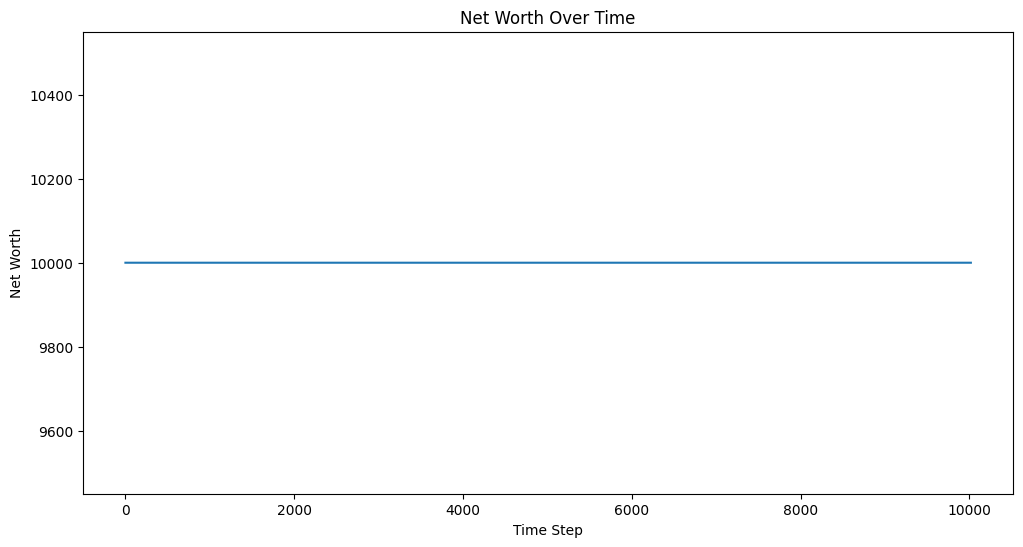

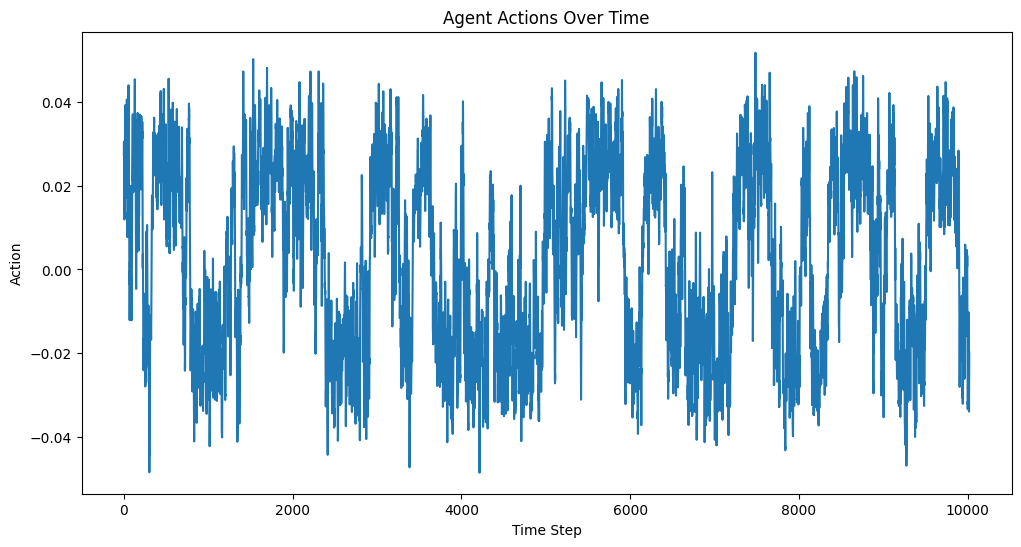

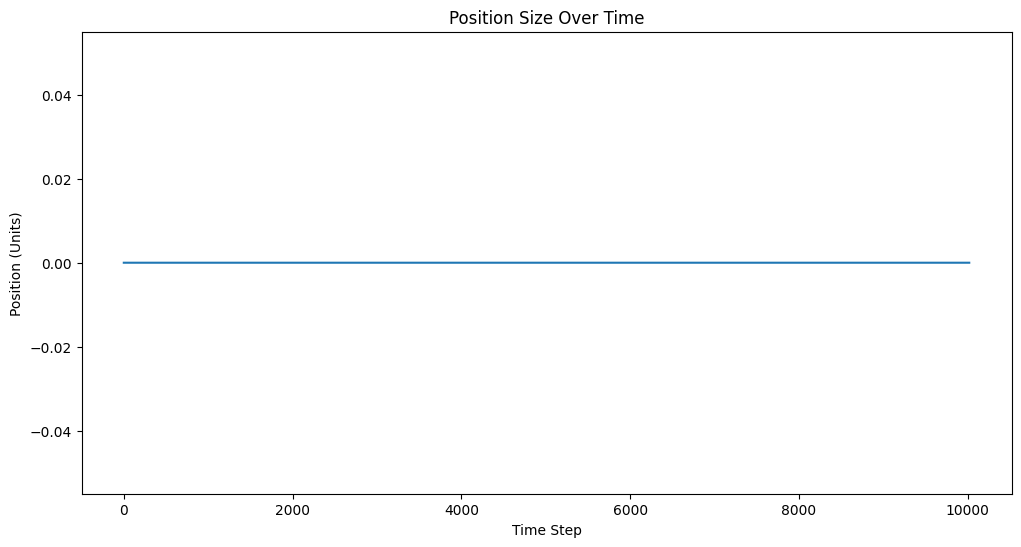

ValueError: x and y must have same first dimension, but have shapes (10019,) and (10020,)

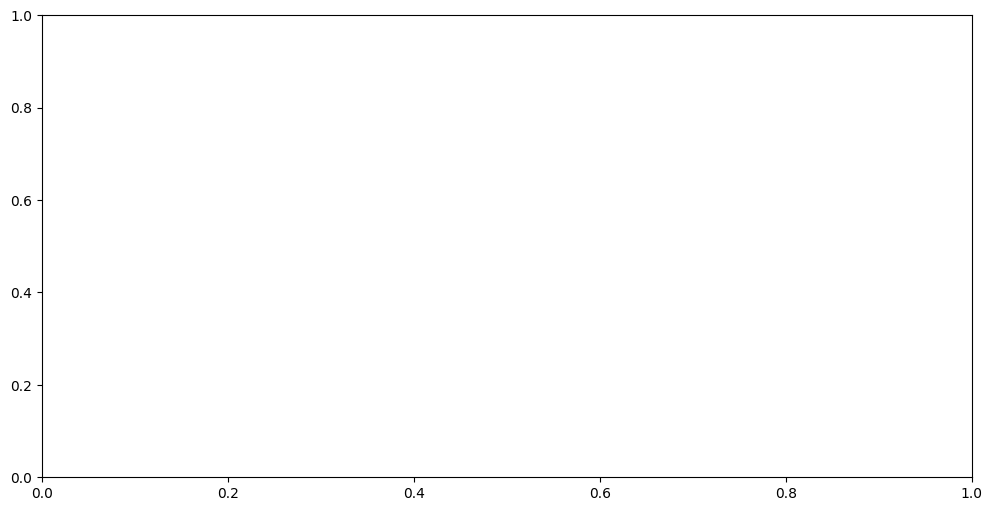

In [25]:
import matplotlib.pyplot as plt

# Convert lists to numpy arrays for easier indexing
net_worths = np.array(test_env.net_worths)
actions = np.array(test_env.actions)
positions = np.array(test_env.positions)
prices = test_env.df['Close'].values[test_env.window_size:test_env.current_step + 1]

# Create a time axis
time_axis = np.arange(len(net_worths))

# Plot Net Worth over Time
plt.figure(figsize=(12, 6))
plt.plot(time_axis, net_worths)
plt.title('Net Worth Over Time')
plt.xlabel('Time Step')
plt.ylabel('Net Worth')
plt.show()

# Plot Actions over Time
plt.figure(figsize=(12, 6))
plt.plot(time_axis, actions)
plt.title('Agent Actions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Action')
plt.show()

# Plot Positions over Time
plt.figure(figsize=(12, 6))
plt.plot(time_axis, positions)
plt.title('Position Size Over Time')
plt.xlabel('Time Step')
plt.ylabel('Position (Units)')
plt.show()

# Plot Price and Actions
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(time_axis, prices, color='blue', label='Price')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(time_axis, actions, color='red', label='Action', alpha=0.6)
ax2.set_ylabel('Action', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Price and Agent Actions Over Time')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()


In [15]:
import pandas as pd
import numpy as np

# Find the minimum length of all arrays
min_length = min(len(net_worths), len(actions), len(positions), len(prices))

# Trim all arrays to the same length
net_worths = net_worths[:min_length]
actions = actions[:min_length]
positions = positions[:min_length]
prices = prices[:min_length]

# Create the DataFrame
df_export = pd.DataFrame({
    'net_worths': net_worths,
    'actions': actions,
    'positions': positions,
    'prices': prices
})

# Save the dataframe to a CSV file
df_export.to_csv('trading_results.csv', index=False)
print("CSV file saved successfully!")


CSV file saved successfully!


In [18]:
print(f"Net Worths length: {len(net_worths)}")
print(f"Actions length: {len(actions)}")
print(f"Positions length: {len(positions)}")
print(f"Prices length: {len(prices)}")


Net Worths length: 10019
Actions length: 10019
Positions length: 10019
Prices length: 10019
